In [1]:
import pandas as pd
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (150000, 12)
Test shape: (101503, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
train_df = train_df.drop("Unnamed: 0", axis=1)
test_df = test_df.drop("Unnamed: 0", axis=1)

train_df.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# ======================================
# XGBOOST FULL PIPELINE
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features and target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# Logistic Regression
# =========================
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_bal, y_train_bal)

log_pred = log_model.predict(X_val_scaled)
log_prob = log_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Random Forest
# =========================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_bal, y_train_bal)

rf_pred = rf_model.predict(X_val_scaled)
rf_prob = rf_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# XGBoost
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

xgb_pred = xgb_model.predict(X_val_scaled)
xgb_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Evaluation
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, pred, prob):
    print(f"\n========== {name} ==========")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))
    print("F1 Score:", f1_score(y_true, pred))
    print("AUC:", roc_auc_score(y_true, prob))

evaluate("LOGISTIC REGRESSION", y_val, log_pred, log_prob)
evaluate("RANDOM FOREST", y_val, rf_pred, rf_prob)
evaluate("XGBOOST", y_val, xgb_pred, xgb_prob)


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# ======================================
# TRAIN + SAVE XGBOOST MODEL
# ======================================

import pandas as pd
import numpy as np
import joblib
import os

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features and target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# Train XGBoost
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

print("XGBoost trained")

# =========================
# Save model + scaler
# =========================
os.makedirs("../ml/models", exist_ok=True)

joblib.dump(xgb_model, "../ml/models/credit_model.pkl")
joblib.dump(scaler, "../ml/models/scaler.pkl")

print("Model and scaler saved successfully")


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:16:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained
Model and scaler saved successfully


In [ ]:
train_df.isnull().sum().sort_values(ascending=False)


MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
age                                         0
RevolvingUtilizationOfUnsecuredLines        0
DebtRatio                                   0
NumberOfTime30-59DaysPastDueNotWorse        0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64

In [ ]:
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)

train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

test_df["MonthlyIncome"] = test_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)

test_df["NumberOfDependents"] = test_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)


In [ ]:
train_df.isnull().sum()



SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [ ]:
# ======================================
# TRAIN + SAVE XGBOOST MODEL
# ======================================

import pandas as pd
import numpy as np
import joblib
import os

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features and target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# Train XGBoost
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

print("XGBoost trained")

# =========================
# Save model + scaler
# =========================
os.makedirs("../ml/models", exist_ok=True)

joblib.dump(xgb_model, "../ml/models/credit_model.pkl")
joblib.dump(scaler, "../ml/models/scaler.pkl")

print("Model and scaler saved successfully")


NameError: name 'xgb_model' is not defined

In [ ]:
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (150000, 10)
Target shape: (150000,)


In [ ]:
y.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

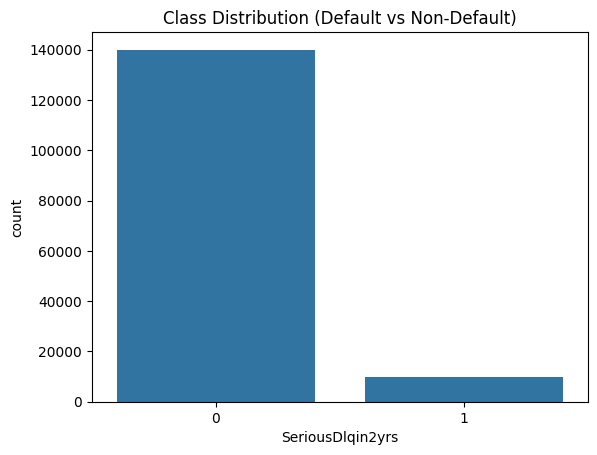

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)
plt.title("Class Distribution (Default vs Non-Default)")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)


(120000, 10) (30000, 10)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [ ]:
!pip install imbalanced-learn


  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np

# Load data
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

# Drop useless column
train_df = train_df.drop("Unnamed: 0", axis=1)
test_df = test_df.drop("Unnamed: 0", axis=1)

# Handle missing values
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

test_df["MonthlyIncome"] = test_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
test_df["NumberOfDependents"] = test_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# Split features and target
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

print("Dataset ready")
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

# Train validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(y_train_bal.value_counts())


Dataset ready
X shape: (150000, 10)
y distribution:
 SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

After SMOTE:
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


In [ ]:
y_pred = log_model.predict(X_val_scaled)
y_prob = log_model.predict_proba(X_val_scaled)[:, 1]

print("Prediction done")


NameError: name 'X_val_scaled' is not defined

In [ ]:
print(type(X_val_scaled))


NameError: name 'X_val_scaled' is not defined

In [ ]:
# =========================
# FULL PIPELINE RESET
# =========================

import pandas as pd
import numpy as np

# Load data
train_df = pd.read_csv("../data/train.csv")

# Drop index column
train_df = train_df.drop("Unnamed: 0", axis=1)

# Handle missing values
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# Features & target
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Train model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_bal, y_train_bal)

# Predict
y_pred = log_model.predict(X_val_scaled)
y_prob = log_model.predict_proba(X_val_scaled)[:, 1]

print("Pipeline + Model + Prediction Ready")


Pipeline + Model + Prediction Ready


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("AUC-ROC:", roc_auc_score(y_val, y_prob))


Accuracy: 0.7554333333333333
Precision: 0.1698043101312856
Recall: 0.6837905236907731
F1 Score: 0.27205079869034626
AUC-ROC: 0.7950980558961589


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_bal, y_train_bal)

print("Random Forest trained")


NameError: name 'X_train_bal' is not defined

In [ ]:
# ======================================
# RANDOM FOREST FULL PIPELINE
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

# Remove useless column
train_df = train_df.drop("Unnamed: 0", axis=1)

# Handle missing values
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features and target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Train validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# SMOTE balancing
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Balanced class distribution:")
print(y_train_bal.value_counts())

# =========================
# Logistic Regression (baseline)
# =========================
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_bal, y_train_bal)

log_pred = log_model.predict(X_val_scaled)
log_prob = log_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Random Forest
# =========================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_bal, y_train_bal)

rf_pred = rf_model.predict(X_val_scaled)
rf_prob = rf_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Evaluation
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n========== LOGISTIC REGRESSION ==========")
print("Accuracy:", accuracy_score(y_val, log_pred))
print("Precision:", precision_score(y_val, log_pred))
print("Recall:", recall_score(y_val, log_pred))
print("F1 Score:", f1_score(y_val, log_pred))
print("AUC:", roc_auc_score(y_val, log_prob))

print("\n========== RANDOM FOREST ==========")
print("Accuracy:", accuracy_score(y_val, rf_pred))
print("Precision:", precision_score(y_val, rf_pred))
print("Recall:", recall_score(y_val, rf_pred))
print("F1 Score:", f1_score(y_val, rf_pred))
print("AUC:", roc_auc_score(y_val, rf_prob))


Balanced class distribution:
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64

========== LOGISTIC REGRESSION ==========
Accuracy: 0.7554333333333333
Precision: 0.1698043101312856
Recall: 0.6837905236907731
F1 Score: 0.27205079869034626
AUC: 0.7950980558961589

========== RANDOM FOREST ==========
Accuracy: 0.9146333333333333
Precision: 0.35728952772073924
Recall: 0.34713216957605986
F1 Score: 0.35213761699974705
AUC: 0.8234709440009549


In [ ]:
# ======================================
# TRAIN + SAVE XGBOOST MODEL
# ======================================

import pandas as pd
import numpy as np
import joblib
import os

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features and target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# Train XGBoost
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

print("XGBoost trained")

# =========================
# Save model + scaler
# =========================
os.makedirs("../ml/models", exist_ok=True)

joblib.dump(xgb_model, "../ml/models/credit_model.pkl")
joblib.dump(scaler, "../ml/models/scaler.pkl")

print("Model and scaler saved successfully")


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:16:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained
Model and scaler saved successfully


In [ ]:
# =========================
# LOAD SAVED MODEL
# =========================

import joblib
import pandas as pd

model = joblib.load("../ml/models/credit_model.pkl")
scaler = joblib.load("../ml/models/scaler.pkl")

print("Model loaded successfully")


Model loaded successfully


In [ ]:
# reload data
train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

X = train_df.drop("SeriousDlqin2yrs", axis=1)

X_sample = X.iloc[:1000]
X_sample_scaled = scaler.transform(X_sample)

print("Sample ready")


Sample ready


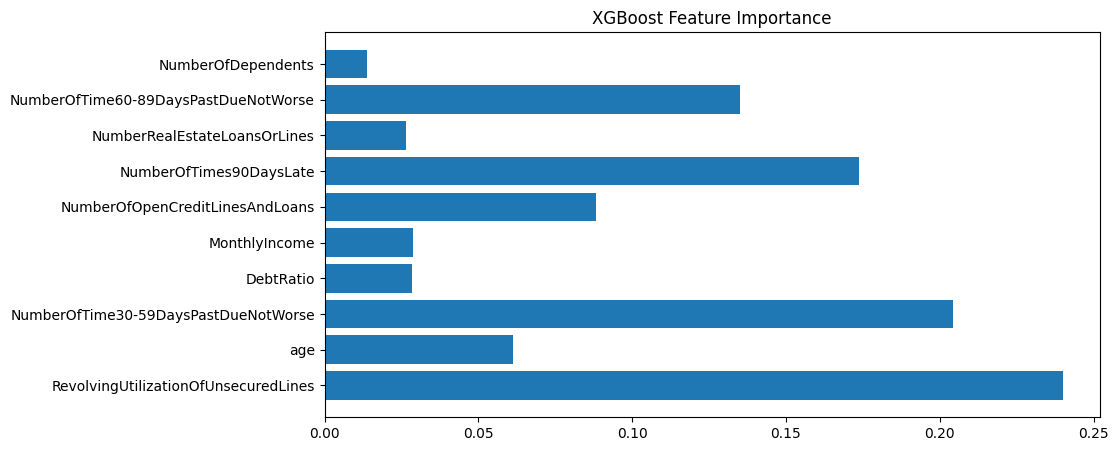

In [ ]:
import matplotlib.pyplot as plt

feature_names = X.columns
importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(feature_names, importances)
plt.title("XGBoost Feature Importance")
plt.show()


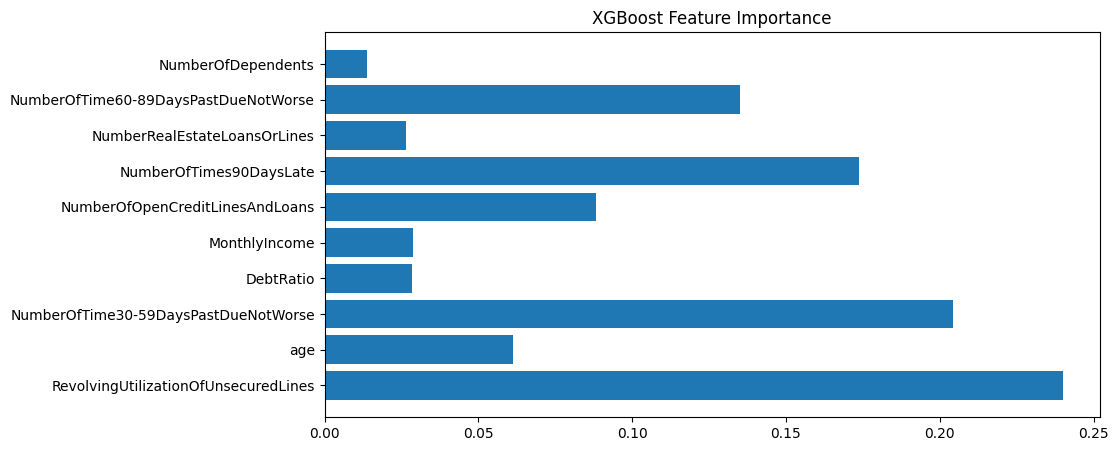

In [ ]:
import matplotlib.pyplot as plt

feature_names = X.columns
importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(feature_names, importances)
plt.title("XGBoost Feature Importance")
plt.show()


In [ ]:
!pip install shap



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


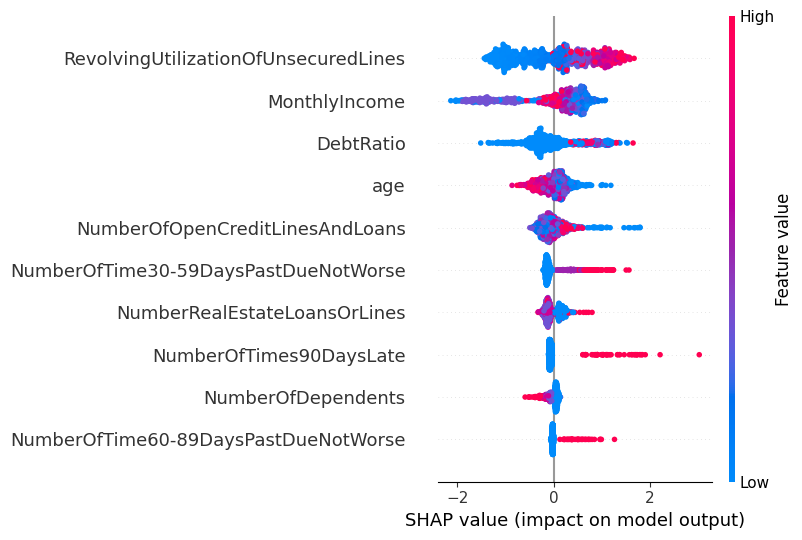

In [ ]:
import shap

explainer = shap.Explainer(model, X_sample_scaled)

shap_values = explainer(X_sample_scaled)

shap.summary_plot(shap_values, X_sample)


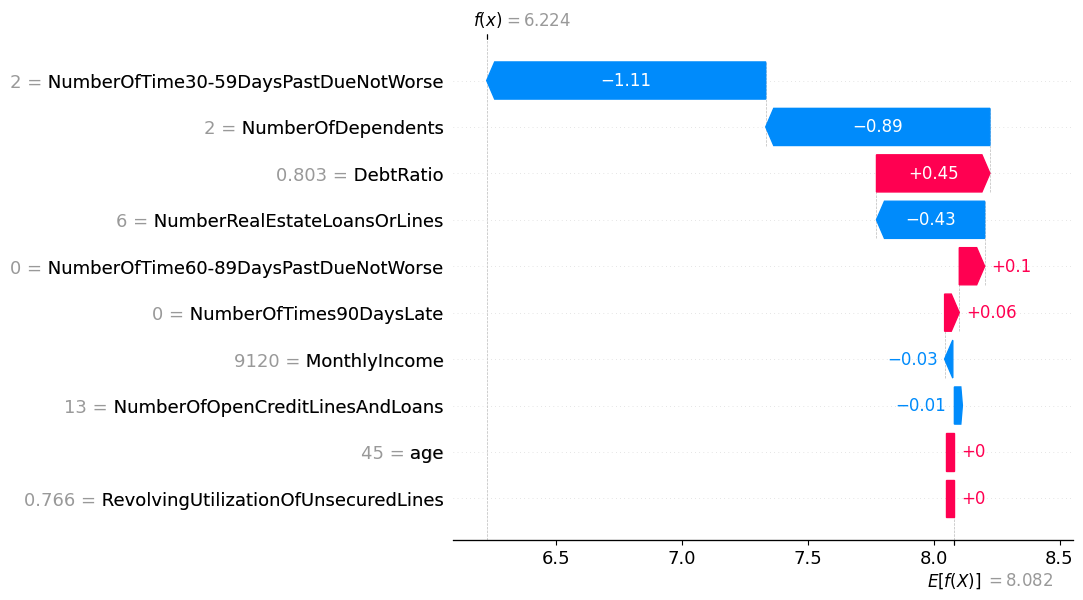

In [ ]:
# Create SHAP values with feature names
explainer = shap.Explainer(model, X_sample)

shap_values = explainer(X_sample)

# Waterfall with feature names
shap.plots.waterfall(shap_values[0])


In [ ]:
!pip install lightgbm


  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ======================================
# LIGHTGBM vs XGBOOST FULL PIPELINE
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features & target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Train validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# XGBoost (reference model)
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

xgb_pred = xgb_model.predict(X_val_scaled)
xgb_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# LightGBM Model
# =========================
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)

lgb_model.fit(X_train_bal, y_train_bal)

lgb_pred = lgb_model.predict(X_val_scaled)
lgb_prob = lgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Evaluation
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, pred, prob):
    print(f"\n========== {name} ==========")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))
    print("F1 Score:", f1_score(y_true, pred))
    print("AUC:", roc_auc_score(y_true, prob))

evaluate("XGBOOST", y_val, xgb_pred, xgb_prob)
evaluate("LIGHTGBM", y_val, lgb_pred, lgb_prob)

[LightGBM] [Info] Number of positive: 111979, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2546
[LightGBM] [Info] Number of data points in the train set: 223958, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

========== XGBOOST ==========
Accuracy: 0.9189
Precision: 0.3902564102564103
Recall: 0.3795511221945137
F1 Score: 0.3848293299620733
AUC: 0.8417723952308905

========== LIGHTGBM ==========
Accuracy: 0.9312333333333334
Precision: 0.47661290322580646
Recall: 0.2947630922693267
F1 Score: 0.36425269645608627
AUC: 0.8519566595210492


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ======================================
# XGBOOST vs LIGHTGBM vs CATBOOST
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features & target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Train validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# XGBoost (reference)
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)
xgb_pred = xgb_model.predict(X_val_scaled)
xgb_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# LightGBM
# =========================
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgb_model.fit(X_train_bal, y_train_bal)
lgb_pred = lgb_model.predict(X_val_scaled)
lgb_prob = lgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# CatBoost
# =========================
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train_bal, y_train_bal)

cat_pred = cat_model.predict(X_val_scaled)
cat_prob = cat_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Evaluation
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, pred, prob):
    print(f"\n========== {name} ==========")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))
    print("F1 Score:", f1_score(y_true, pred))
    print("AUC:", roc_auc_score(y_true, prob))

evaluate("XGBOOST", y_val, xgb_pred, xgb_prob)
evaluate("LIGHTGBM", y_val, lgb_pred, lgb_prob)
evaluate("CATBOOST", y_val, cat_pred, cat_prob)

[LightGBM] [Info] Number of positive: 111979, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2546
[LightGBM] [Info] Number of data points in the train set: 223958, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



========== XGBOOST ==========
Accuracy: 0.9189
Precision: 0.3902564102564103
Recall: 0.3795511221945137
F1 Score: 0.3848293299620733
AUC: 0.8417723952308905

========== LIGHTGBM ==========
Accuracy: 0.9312333333333334
Precision: 0.47661290322580646
Recall: 0.2947630922693267
F1 Score: 0.36425269645608627
AUC: 0.8519566595210492

========== CATBOOST ==========
Accuracy: 0.9297666666666666
Precision: 0.4636752136752137
Recall: 0.32468827930174565
F1 Score: 0.38193018480492813
AUC: 0.854466771096905


In [ ]:
# ======================================
# LOANPALZ FEATURE ENGINEERING PIPELINE
# ======================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# =========================
# 1. LOAD DATA
# =========================
train_df = pd.read_csv("../data/train.csv")

# remove useless column
train_df = train_df.drop("Unnamed: 0", axis=1)

# =========================
# 2. HANDLE MISSING VALUES
# =========================
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)

train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# 3. OUTLIER HANDLING (CLIPPING)
# =========================
clip_cols = [
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines"
]

for col in clip_cols:
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    train_df[col] = train_df[col].clip(lower, upper)

# =========================
# 4. NORMALIZATION (0–1 SCALE)
# =========================
normalize_cols = [
    "MonthlyIncome",
    "NumberOfDependents",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "age"
]

scaler = MinMaxScaler()
train_df[normalize_cols] = scaler.fit_transform(train_df[normalize_cols])

# =========================
# 5. BEHAVIORAL CREDIT INDICES
# =========================

# ---- Financial Stability Index (FSI)
train_df["FSI"] = (
    train_df["MonthlyIncome"] *
    (1 - train_df["DebtRatio"]) *
    (1 / (1 + train_df["NumberOfDependents"]))
)

# ---- Payment Discipline Score (PDS)
train_df["PDS"] = 1 / (
    1
    + 0.2 * train_df["NumberOfTime30-59DaysPastDueNotWorse"]
    + 0.3 * train_df["NumberOfTime60-89DaysPastDueNotWorse"]
    + 0.5 * train_df["NumberOfTimes90DaysLate"]
)

# ---- Total loans
train_df["TotalLoans"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"]
    + train_df["NumberRealEstateLoansOrLines"]
)

# ---- Debt Stress Index (DSI)
train_df["DSI"] = (
    train_df["DebtRatio"]
    + train_df["RevolvingUtilizationOfUnsecuredLines"]
) * np.log1p(train_df["TotalLoans"])

# ---- Credit Utilization Risk Score (CURS)
train_df["CURS"] = (
    train_df["RevolvingUtilizationOfUnsecuredLines"]
    / (1 + train_df["NumberOfOpenCreditLinesAndLoans"])
)

# =========================
# 6. FINAL DATASET
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

print("✅ Feature engineering complete")
print("New dataset shape:", X.shape)
print("\nNew columns added:")
print(["FSI", "PDS", "DSI", "CURS"])

✅ Feature engineering complete
New dataset shape: (150000, 15)

New columns added:
['FSI', 'PDS', 'DSI', 'CURS']


In [ ]:
# ======================================
# XGBOOST WITH BEHAVIORAL FEATURES
# ======================================

import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================
train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

# =========================
# HANDLE MISSING VALUES
# =========================
train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)

train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# OUTLIER CLIPPING
# =========================
clip_cols = [
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines"
]

for col in clip_cols:
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    train_df[col] = train_df[col].clip(lower, upper)

# =========================
# NORMALIZATION
# =========================
from sklearn.preprocessing import MinMaxScaler

normalize_cols = [
    "MonthlyIncome",
    "NumberOfDependents",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "age"
]

scaler_norm = MinMaxScaler()
train_df[normalize_cols] = scaler_norm.fit_transform(train_df[normalize_cols])

# =========================
# BEHAVIORAL INDICES
# =========================

# Financial Stability Index
train_df["FSI"] = (
    train_df["MonthlyIncome"] *
    (1 - train_df["DebtRatio"]) *
    (1 / (1 + train_df["NumberOfDependents"]))
)

# Payment Discipline Score
train_df["PDS"] = 1 / (
    1
    + 0.2 * train_df["NumberOfTime30-59DaysPastDueNotWorse"]
    + 0.3 * train_df["NumberOfTime60-89DaysPastDueNotWorse"]
    + 0.5 * train_df["NumberOfTimes90DaysLate"]
)

# Total Loans
train_df["TotalLoans"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"]
    + train_df["NumberRealEstateLoansOrLines"]
)

# Debt Stress Index
train_df["DSI"] = (
    train_df["DebtRatio"]
    + train_df["RevolvingUtilizationOfUnsecuredLines"]
) * np.log1p(train_df["TotalLoans"])

# Credit Utilization Risk Score
train_df["CURS"] = (
    train_df["RevolvingUtilizationOfUnsecuredLines"]
    / (1 + train_df["NumberOfOpenCreditLinesAndLoans"])
)

# =========================
# FEATURES & TARGET
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# STANDARD SCALING FOR MODEL
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# SMOTE BALANCING
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# TRAIN XGBOOST
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

# =========================
# EVALUATION
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pred = xgb_model.predict(X_val_scaled)
prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

print("\n===== XGBoost + Behavioral Features =====")
print("Accuracy:", accuracy_score(y_val, pred))
print("Precision:", precision_score(y_val, pred))
print("Recall:", recall_score(y_val, pred))
print("F1 Score:", f1_score(y_val, pred))
print("AUC:", roc_auc_score(y_val, prob))


===== XGBoost + Behavioral Features =====
Accuracy: 0.9213
Precision: 0.40738813735691987
Recall: 0.3905236907730673
F1 Score: 0.39877769289533993
AUC: 0.8496298991759751


In [ ]:
# ======================================
# LOANPALZ CREDIT RISK SYSTEM
# ======================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

RANDOM_STATE = 42

In [ ]:
# =========================
# LOAD DATA
# =========================

train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
# =========================
# MISSING VALUES
# =========================

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)

train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

print("Missing values handled")

Missing values handled


In [ ]:
# =========================
# OUTLIER CLIPPING
# =========================

clip_cols = [
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines"
]

for col in clip_cols:
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    train_df[col] = train_df[col].clip(lower, upper)

print("Outliers clipped")

Outliers clipped


In [ ]:
# =========================
# MIN-MAX NORMALIZATION
# =========================

normalize_cols = [
    "MonthlyIncome",
    "NumberOfDependents",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "age"
]

scaler_norm = MinMaxScaler()
train_df[normalize_cols] = scaler_norm.fit_transform(train_df[normalize_cols])

print("Normalization complete")

Normalization complete


In [ ]:
# ======================================
# BEHAVIORAL CREDIT INDICES
# ======================================

# Financial Stability Index
train_df["FSI"] = (
    train_df["MonthlyIncome"]
    * (1 - train_df["DebtRatio"])
    * (1 / (1 + train_df["NumberOfDependents"]))
)

# Payment Discipline Score
train_df["PDS"] = 1 / (
    1
    + 0.2 * train_df["NumberOfTime30-59DaysPastDueNotWorse"]
    + 0.3 * train_df["NumberOfTime60-89DaysPastDueNotWorse"]
    + 0.5 * train_df["NumberOfTimes90DaysLate"]
)

# Total Loans
train_df["TotalLoans"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"]
    + train_df["NumberRealEstateLoansOrLines"]
)

# Debt Stress Index
train_df["DSI"] = (
    train_df["DebtRatio"]
    + train_df["RevolvingUtilizationOfUnsecuredLines"]
) * np.log1p(train_df["TotalLoans"])

# Credit Utilization Risk Score
train_df["CURS"] = (
    train_df["RevolvingUtilizationOfUnsecuredLines"]
    / (1 + train_df["NumberOfOpenCreditLinesAndLoans"])
)

print("Behavioral features created")
train_df[["FSI","PDS","DSI","CURS"]].describe()

Behavioral features created


,FSI,PDS,DSI,CURS
count,150000.000000,150000.000000,150000.000000,150000.000000
mean,-68.479370,0.937025,177.862121,0.250070
std,203.950660,0.147070,597.404410,0.292883
min,-1168.757217,0.010101,0.000000,0.000000
25%,0.014243,1.000000,0.117683,0.022042
50%,0.118771,1.000000,0.325519,0.111568
75%,0.219652,1.000000,0.886866,0.405419
max,1.000000,1.000000,5471.014016,1.092956


In [ ]:
# =========================
# FEATURES & TARGET
# =========================

X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

print("Feature shape:", X.shape)

Feature shape: (150000, 15)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (120000, 15)
Validation: (30000, 15)


In [ ]:
# =========================
# SCALING + CLASS BALANCING
# =========================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE applied")
print(y_train_bal.value_counts())

SMOTE applied
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


In [ ]:
# =========================
# FINAL MODEL TRAINING
# =========================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

xgb_model.fit(X_train_bal, y_train_bal)

print("Model trained")

Model trained


In [ ]:
# =========================
# EVALUATION
# =========================

pred = xgb_model.predict(X_val_scaled)
prob = xgb_model.predict_proba(X_val_scaled)[:,1]

print("Accuracy:", accuracy_score(y_val, pred))
print("Precision:", precision_score(y_val, pred))
print("Recall:", recall_score(y_val, pred))
print("F1:", f1_score(y_val, pred))
print("AUC:", roc_auc_score(y_val, prob))

Accuracy: 0.9213
Precision: 0.40738813735691987
Recall: 0.3905236907730673
F1: 0.39877769289533993
AUC: 0.8496298991759751


In [ ]:
# =========================
# SAVE MODEL
# =========================

import joblib
import os

os.makedirs("../ml/models", exist_ok=True)

joblib.dump(xgb_model, "../ml/models/loanpalz_model.pkl")
joblib.dump(scaler, "../ml/models/scaler.pkl")

print("Model saved")

Model saved


In [ ]:
# ======================================
# LIGHTGBM vs XGBOOST FULL PIPELINE
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features & target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Train validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# XGBoost (reference model)
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

xgb_pred = xgb_model.predict(X_val_scaled)
xgb_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# LightGBM Model
# =========================
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)

lgb_model.fit(X_train_bal, y_train_bal)

lgb_pred = lgb_model.predict(X_val_scaled)
lgb_prob = lgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Evaluation
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, pred, prob):
    print(f"\n========== {name} ==========")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))
    print("F1 Score:", f1_score(y_true, pred))
    print("AUC:", roc_auc_score(y_true, prob))

evaluate("XGBOOST", y_val, xgb_pred, xgb_prob)
evaluate("LIGHTGBM", y_val, lgb_pred, lgb_prob)

[LightGBM] [Info] Number of positive: 111979, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006350 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2546
[LightGBM] [Info] Number of data points in the train set: 223958, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

========== XGBOOST ==========
Accuracy: 0.9189
Precision: 0.3902564102564103
Recall: 0.3795511221945137
F1 Score: 0.3848293299620733
AUC: 0.8417723952308905

========== LIGHTGBM ==========
Accuracy: 0.9312333333333334
Precision: 0.47661290322580646
Recall: 0.2947630922693267
F1 Score: 0.36425269645608627
AUC: 0.8519566595210492


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ======================================
# CATBOOST vs LIGHTGBM vs XGBOOST
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Features & target
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# Train validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# SMOTE
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# XGBoost
# =========================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_bal, y_train_bal)

xgb_pred = xgb_model.predict(X_val_scaled)
xgb_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# LightGBM
# =========================
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgb_model.fit(X_train_bal, y_train_bal)

lgb_pred = lgb_model.predict(X_val_scaled)
lgb_prob = lgb_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# CatBoost
# =========================
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

cat_model.fit(X_train_bal, y_train_bal)

cat_pred = cat_model.predict(X_val_scaled)
cat_prob = cat_model.predict_proba(X_val_scaled)[:, 1]

# =========================
# Evaluation
# =========================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, pred, prob):
    print(f"\n========== {name} ==========")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))
    print("F1 Score:", f1_score(y_true, pred))
    print("AUC:", roc_auc_score(y_true, prob))

evaluate("XGBOOST", y_val, xgb_pred, xgb_prob)
evaluate("LIGHTGBM", y_val, lgb_pred, lgb_prob)
evaluate("CATBOOST", y_val, cat_pred, cat_prob)

[LightGBM] [Info] Number of positive: 111979, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2546
[LightGBM] [Info] Number of data points in the train set: 223958, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aakas\LoanPalz\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



========== XGBOOST ==========
Accuracy: 0.9189
Precision: 0.3902564102564103
Recall: 0.3795511221945137
F1 Score: 0.3848293299620733
AUC: 0.8417723952308905

========== LIGHTGBM ==========
Accuracy: 0.9312333333333334
Precision: 0.47661290322580646
Recall: 0.2947630922693267
F1 Score: 0.36425269645608627
AUC: 0.8519566595210492

========== CATBOOST ==========
Accuracy: 0.9297666666666666
Precision: 0.4636752136752137
Recall: 0.32468827930174565
F1 Score: 0.38193018480492813
AUC: 0.854466771096905


In [ ]:
# ======================================
# BEHAVIORAL CREDIT INDICES + CATBOOST
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")

train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# SAVE COPY (baseline features)
# =========================
baseline_df = train_df.copy()

# =========================
# CREATE BEHAVIORAL INDICES
# =========================

# 1️⃣ Financial Stability Index
train_df["FinancialStabilityIndex"] = (
    train_df["MonthlyIncome"] /
    (train_df["DebtRatio"] * 1000 + train_df["NumberOfDependents"] + 1)
)

# 2️⃣ Payment Discipline Score
train_df["PaymentDisciplineScore"] = 1 / (
    train_df["NumberOfTime30-59DaysPastDueNotWorse"] +
    train_df["NumberOfTime60-89DaysPastDueNotWorse"] +
    train_df["NumberOfTimes90DaysLate"] + 1
)

# 3️⃣ Debt Stress Index
train_df["DebtStressIndex"] = (
    train_df["DebtRatio"] *
    train_df["RevolvingUtilizationOfUnsecuredLines"] *
    (train_df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

# 4️⃣ Credit Utilization Risk Score
train_df["CreditUtilizationRisk"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
]

# 5️⃣ Credit Experience Score
train_df["CreditExperienceScore"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] +
    train_df["NumberRealEstateLoansOrLines"]
)

print("Behavioral features created")

# =========================
# FUNCTION TO TRAIN CATBOOST
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def train_catboost(df, label="MODEL"):

    X = df.drop("SeriousDlqin2yrs", axis=1)
    y = df["SeriousDlqin2yrs"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

    model = CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        random_state=42,
        verbose=False
    )

    model.fit(X_train_bal, y_train_bal)

    pred = model.predict(X_val_scaled)
    prob = model.predict_proba(X_val_scaled)[:, 1]

    print(f"\n========== {label} ==========")
    print("Accuracy:", accuracy_score(y_val, pred))
    print("Precision:", precision_score(y_val, pred))
    print("Recall:", recall_score(y_val, pred))
    print("F1 Score:", f1_score(y_val, pred))
    print("AUC:", roc_auc_score(y_val, prob))

    return model


# =========================
# BASELINE MODEL
# =========================
baseline_model = train_catboost(baseline_df, "BASELINE CATBOOST")

# =========================
# BEHAVIORAL MODEL
# =========================
behavior_model = train_catboost(train_df, "BEHAVIORAL CATBOOST")

Behavioral features created

========== BASELINE CATBOOST ==========
Accuracy: 0.9297666666666666
Precision: 0.4636752136752137
Recall: 0.32468827930174565
F1 Score: 0.38193018480492813
AUC: 0.854466771096905

========== BEHAVIORAL CATBOOST ==========
Accuracy: 0.9313333333333333
Precision: 0.4804270462633452
Recall: 0.33665835411471323
F1 Score: 0.39589442815249265
AUC: 0.8528385412607079


In [ ]:
# ======================================
# FAIRNESS & BIAS ANALYSIS
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data again
# =========================
train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Create behavioral features (same as before)
# =========================
train_df["FinancialStabilityIndex"] = (
    train_df["MonthlyIncome"] /
    (train_df["DebtRatio"] * 1000 + train_df["NumberOfDependents"] + 1)
)

train_df["PaymentDisciplineScore"] = 1 / (
    train_df["NumberOfTime30-59DaysPastDueNotWorse"] +
    train_df["NumberOfTime60-89DaysPastDueNotWorse"] +
    train_df["NumberOfTimes90DaysLate"] + 1
)

train_df["DebtStressIndex"] = (
    train_df["DebtRatio"] *
    train_df["RevolvingUtilizationOfUnsecuredLines"] *
    (train_df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

train_df["CreditUtilizationRisk"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
]

train_df["CreditExperienceScore"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] +
    train_df["NumberRealEstateLoansOrLines"]
)

# =========================
# Split
# =========================
from sklearn.model_selection import train_test_split

X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Scale + SMOTE
# =========================
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# =========================
# Train behavioral CatBoost
# =========================
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

model.fit(X_train_bal, y_train_bal)

# predictions
y_pred = model.predict(X_val_scaled)

# =========================
# AGE GROUP FAIRNESS
# =========================
X_val_copy = X_val.copy()
X_val_copy["actual"] = y_val.values
X_val_copy["pred"] = y_pred

# create age bins
X_val_copy["age_group"] = pd.cut(
    X_val_copy["age"],
    bins=[0,30,50,100],
    labels=["Young","Middle","Senior"]
)

print("\n===== AGE GROUP PERFORMANCE =====")

for group in X_val_copy["age_group"].unique():
    subset = X_val_copy[X_val_copy["age_group"] == group]
    acc = (subset["actual"] == subset["pred"]).mean()
    print(group, "accuracy:", acc, "size:", len(subset))


# =========================
# INCOME GROUP FAIRNESS
# =========================
X_val_copy["income_group"] = pd.qcut(
    X_val_copy["MonthlyIncome"],
    q=3,
    labels=["Low","Medium","High"]
)

print("\n===== INCOME GROUP PERFORMANCE =====")

for group in X_val_copy["income_group"].unique():
    subset = X_val_copy[X_val_copy["income_group"] == group]
    acc = (subset["actual"] == subset["pred"]).mean()
    print(group, "accuracy:", acc, "size:", len(subset))


# =========================
# DISPARATE IMPACT RATIO
# =========================

approval_rate = 1 - X_val_copy["pred"]

group_rates = X_val_copy.groupby("income_group")["pred"].mean()

print("\n===== DISPARATE IMPACT (DEFAULT RATE) =====")
print(group_rates)

print("\nFairness rule:")
print("Ratio < 0.8 indicates possible bias")


===== AGE GROUP PERFORMANCE =====
Senior accuracy: 0.9591490963855421 size: 15936
Middle accuracy: 0.9090832914362326 size: 11934
Young accuracy: 0.847457627118644 size: 2124
nan accuracy: nan size: 0

===== INCOME GROUP PERFORMANCE =====
Medium accuracy: 0.9367907624925343 size: 10046
Low accuracy: 0.904009599040096 size: 10001
High accuracy: 0.9532804179644329 size: 9953

===== DISPARATE IMPACT (DEFAULT RATE) =====
income_group
Low       0.076792
Medium    0.042704
High      0.020898
Name: pred, dtype: float64

Fairness rule:
Ratio < 0.8 indicates possible bias


c:\Users\aakas\LoanPalz\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Behavioral model trained


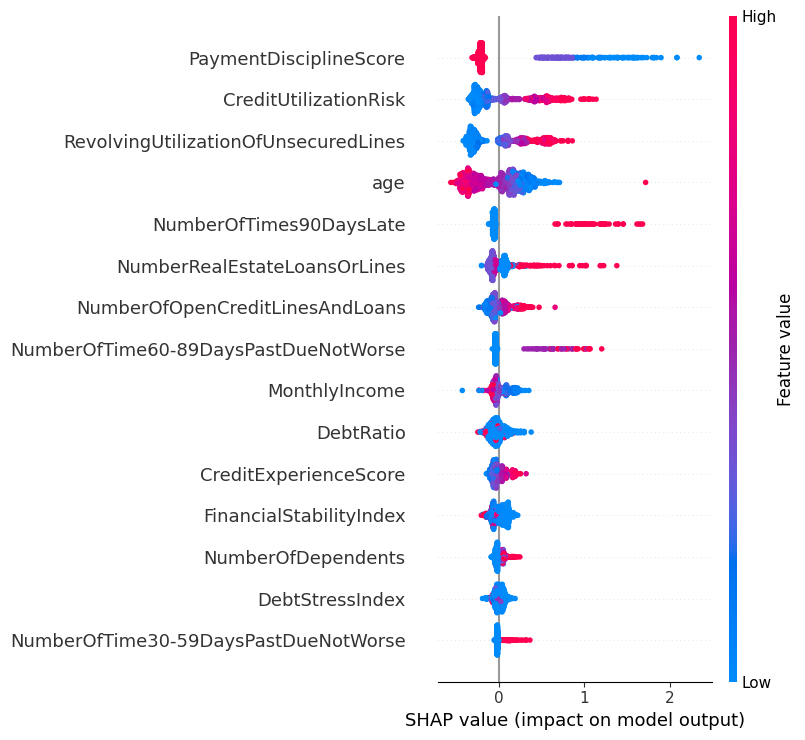

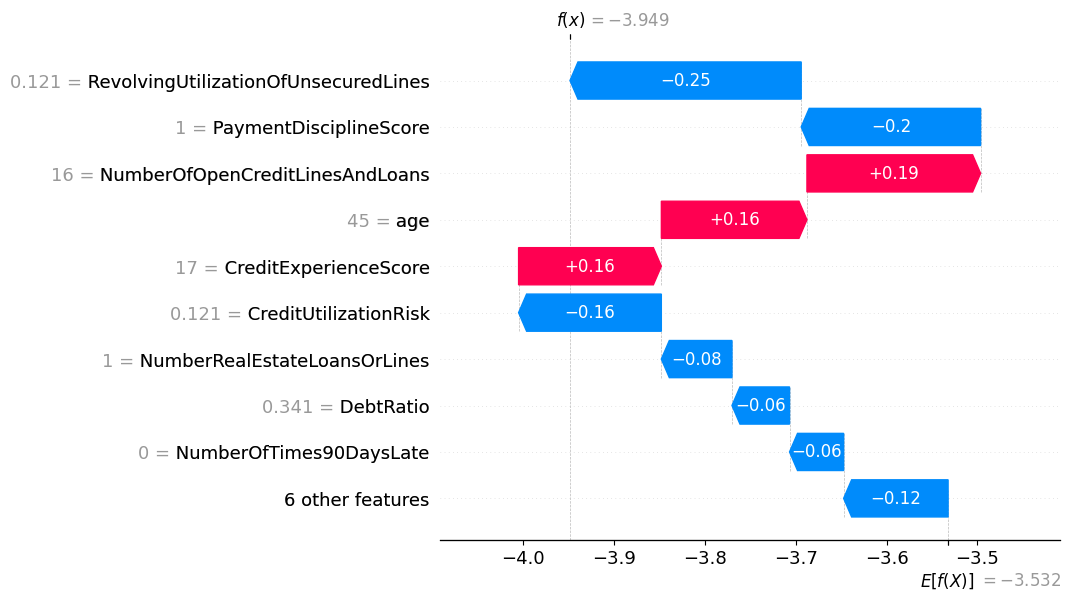

In [ ]:
# ======================================
# SHAP EXPLAINABILITY FOR BEHAVIORAL MODEL
# ======================================

import pandas as pd
import numpy as np
import shap

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Create behavioral features
# =========================
train_df["FinancialStabilityIndex"] = (
    train_df["MonthlyIncome"] /
    (train_df["DebtRatio"] * 1000 + train_df["NumberOfDependents"] + 1)
)

train_df["PaymentDisciplineScore"] = 1 / (
    train_df["NumberOfTime30-59DaysPastDueNotWorse"] +
    train_df["NumberOfTime60-89DaysPastDueNotWorse"] +
    train_df["NumberOfTimes90DaysLate"] + 1
)

train_df["DebtStressIndex"] = (
    train_df["DebtRatio"] *
    train_df["RevolvingUtilizationOfUnsecuredLines"] *
    (train_df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

train_df["CreditUtilizationRisk"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
]

train_df["CreditExperienceScore"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] +
    train_df["NumberRealEstateLoansOrLines"]
)

# =========================
# Split
# =========================
from sklearn.model_selection import train_test_split

X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Train behavioral CatBoost (no scaling needed for SHAP clarity)
# =========================
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

model.fit(X_train, y_train)

print("Behavioral model trained")

# =========================
# SHAP EXPLANATION
# =========================
explainer = shap.TreeExplainer(model)

sample = X_val.sample(1000, random_state=42)

shap_values = explainer.shap_values(sample)

# Global importance
shap.summary_plot(shap_values, sample)

# Local explanation
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

In [ ]:
# ======================================
# BIAS MITIGATION — REWEIGHTING APPROACH
# ======================================

import pandas as pd
import numpy as np

# =========================
# Load data
# =========================
train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# Behavioral features
# =========================
train_df["FinancialStabilityIndex"] = (
    train_df["MonthlyIncome"] /
    (train_df["DebtRatio"] * 1000 + train_df["NumberOfDependents"] + 1)
)

train_df["PaymentDisciplineScore"] = 1 / (
    train_df["NumberOfTime30-59DaysPastDueNotWorse"] +
    train_df["NumberOfTime60-89DaysPastDueNotWorse"] +
    train_df["NumberOfTimes90DaysLate"] + 1
)

train_df["DebtStressIndex"] = (
    train_df["DebtRatio"] *
    train_df["RevolvingUtilizationOfUnsecuredLines"] *
    (train_df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

train_df["CreditUtilizationRisk"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
]

train_df["CreditExperienceScore"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] +
    train_df["NumberRealEstateLoansOrLines"]
)

# =========================
# Create income groups
# =========================
train_df["income_group"] = pd.qcut(
    train_df["MonthlyIncome"],
    q=3,
    labels=["Low","Medium","High"]
)

# =========================
# Clean dataset (IMPORTANT)
# =========================
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df.fillna(train_df.median(numeric_only=True), inplace=True)

# =========================
# Assign fairness weights
# =========================
weight_map = {"Low": 2.0, "Medium": 1.2, "High": 1.0}

weights = train_df["income_group"].map(weight_map).astype(float).values

# =========================
# Split
# =========================
from sklearn.model_selection import train_test_split

X = train_df.drop(["SeriousDlqin2yrs","income_group"], axis=1)
y = train_df["SeriousDlqin2yrs"]

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Train weighted CatBoost
# =========================
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

model.fit(X_train, y_train, sample_weight=w_train)

print("Fairness-aware model trained")

# =========================
# Evaluate fairness
# =========================
y_pred = model.predict(X_val)

X_val_copy = X_val.copy()
X_val_copy["actual"] = y_val.values
X_val_copy["pred"] = y_pred
X_val_copy["MonthlyIncome"] = X_val["MonthlyIncome"]

X_val_copy["income_group"] = pd.qcut(
    X_val_copy["MonthlyIncome"],
    q=3,
    labels=["Low","Medium","High"]
)

print("\n===== FAIRNESS AFTER MITIGATION =====")

for group in X_val_copy["income_group"].unique():
    subset = X_val_copy[X_val_copy["income_group"] == group]
    acc = (subset["actual"] == subset["pred"]).mean()
    default_rate = subset["pred"].mean()
    print(group, "accuracy:", acc, "default rate:", default_rate)

Fairness-aware model trained

===== FAIRNESS AFTER MITIGATION =====
Medium accuracy: 0.941270157276528 default rate: 0.02170017917579136
Low accuracy: 0.9162083791620838 default rate: 0.031996800319968
High accuracy: 0.9527780568672762 default rate: 0.009142971968250778


In [ ]:
# ======================================
# LOANPALZ HYBRID RISK DECISION ENGINE
# ======================================

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier

# =========================
# Train final behavioral model (production model)
# =========================
train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# Behavioral features
train_df["FinancialStabilityIndex"] = (
    train_df["MonthlyIncome"] /
    (train_df["DebtRatio"] * 1000 + train_df["NumberOfDependents"] + 1)
)

train_df["PaymentDisciplineScore"] = 1 / (
    train_df["NumberOfTime30-59DaysPastDueNotWorse"] +
    train_df["NumberOfTime60-89DaysPastDueNotWorse"] +
    train_df["NumberOfTimes90DaysLate"] + 1
)

train_df["DebtStressIndex"] = (
    train_df["DebtRatio"] *
    train_df["RevolvingUtilizationOfUnsecuredLines"] *
    (train_df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

train_df["CreditUtilizationRisk"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
]

train_df["CreditExperienceScore"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] +
    train_df["NumberRealEstateLoansOrLines"]
)

X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

model.fit(X, y)

print("Production model trained")


# ======================================
# HYBRID CREDIT SCORING FUNCTION
# ======================================

def hybrid_credit_score(borrower):

    borrower = borrower.copy()

    # =========================
    # CREATE BEHAVIORAL FEATURES
    # =========================
    borrower["FinancialStabilityIndex"] = (
        borrower["MonthlyIncome"] /
        (borrower["DebtRatio"] * 1000 + borrower["NumberOfDependents"] + 1)
    )

    borrower["PaymentDisciplineScore"] = 1 / (
        borrower["NumberOfTime30-59DaysPastDueNotWorse"] +
        borrower["NumberOfTime60-89DaysPastDueNotWorse"] +
        borrower["NumberOfTimes90DaysLate"] + 1
    )

    borrower["DebtStressIndex"] = (
        borrower["DebtRatio"] *
        borrower["RevolvingUtilizationOfUnsecuredLines"] *
        (borrower["NumberOfOpenCreditLinesAndLoans"] + 1)
    )

    borrower["CreditUtilizationRisk"] = borrower[
        "RevolvingUtilizationOfUnsecuredLines"
    ]

    borrower["CreditExperienceScore"] = (
        borrower["NumberOfOpenCreditLinesAndLoans"] +
        borrower["NumberRealEstateLoansOrLines"]
    )

    df = pd.DataFrame([borrower])

    # =========================
    # MODEL PREDICTION
    # =========================
    base_risk = model.predict_proba(df)[0][1]

    adjustment = 0
    reasons = []

    # =========================
    # RULE 1 — PAYMENT DISCIPLINE
    # =========================
    if borrower["PaymentDisciplineScore"] < 0.5:
        adjustment += 0.10
        reasons.append("Poor payment discipline (+risk)")

    # =========================
    # RULE 2 — FINANCIAL STABILITY
    # =========================
    if borrower["FinancialStabilityIndex"] > 2000:
        adjustment -= 0.05
        reasons.append("High financial stability (-risk)")

    # =========================
    # RULE 3 — DEBT STRESS
    # =========================
    if borrower["DebtStressIndex"] > 5:
        adjustment += 0.08
        reasons.append("High debt stress (+risk)")

    # =========================
    # RULE 4 — CREDIT EXPERIENCE
    # =========================
    if borrower["CreditExperienceScore"] > 10:
        adjustment -= 0.03
        reasons.append("Strong credit experience (-risk)")

    # =========================
    # RULE 5 — FAIRNESS ADJUSTMENT
    # =========================
    if borrower["MonthlyIncome"] < 3000 and base_risk < 0.5:
        adjustment -= 0.03
        reasons.append("Fairness adjustment for low income (-risk)")

    # =========================
    # FINAL RISK
    # =========================
    final_risk = min(max(base_risk + adjustment, 0), 1)

    # credit score 300–900
    credit_score = int((1 - final_risk) * 600 + 300)

    # risk category
    if final_risk < 0.3:
        risk_category = "Low"
    elif final_risk < 0.6:
        risk_category = "Medium"
    else:
        risk_category = "High"

    return {
        "base_model_risk": round(base_risk, 3),
        "final_risk": round(final_risk, 3),
        "credit_score": credit_score,
        "risk_category": risk_category,
        "adjustments": reasons
    }


# ======================================
# TEST SAMPLE BORROWER
# ======================================

sample_borrower = {
    "RevolvingUtilizationOfUnsecuredLines": 0.7,
    "age": 35,
    "NumberOfTime30-59DaysPastDueNotWorse": 1,
    "DebtRatio": 0.8,
    "MonthlyIncome": 2500,
    "NumberOfOpenCreditLinesAndLoans": 5,
    "NumberOfTimes90DaysLate": 0,
    "NumberRealEstateLoansOrLines": 1,
    "NumberOfTime60-89DaysPastDueNotWorse": 0,
    "NumberOfDependents": 2
}

result = hybrid_credit_score(sample_borrower)
print("\nHybrid Decision Output:")
print(result)

Production model trained

Hybrid Decision Output:
{'base_model_risk': np.float64(0.142), 'final_risk': np.float64(0.112), 'credit_score': 832, 'risk_category': 'Low', 'adjustments': ['Fairness adjustment for low income (-risk)']}


In [1]:
# ======================================
# TRAIN FINAL PRODUCTION MODEL (15 FEATURES)
# ======================================

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
import joblib
import os
import json
from datetime import datetime

# =========================
# LOAD DATA
# =========================
train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# =========================
# BEHAVIORAL FEATURES
# =========================
train_df["FinancialStabilityIndex"] = (
    train_df["MonthlyIncome"] /
    (train_df["DebtRatio"] * 1000 + train_df["NumberOfDependents"] + 1)
)

train_df["PaymentDisciplineScore"] = 1 / (
    train_df["NumberOfTime30-59DaysPastDueNotWorse"] +
    train_df["NumberOfTime60-89DaysPastDueNotWorse"] +
    train_df["NumberOfTimes90DaysLate"] + 1
)

train_df["DebtStressIndex"] = (
    train_df["DebtRatio"] *
    train_df["RevolvingUtilizationOfUnsecuredLines"] *
    (train_df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

train_df["CreditUtilizationRisk"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
]

train_df["CreditExperienceScore"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] +
    train_df["NumberRealEstateLoansOrLines"]
)

# =========================
# FEATURES & TARGET
# =========================
X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

# =========================
# TRAIN MODEL
# =========================
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

model.fit(X, y)

print("Final behavioral model trained")

# =========================
# MODEL VERSIONING SYSTEM
# =========================

MODEL_DIR = "../ml/models"
REGISTRY_PATH = os.path.join(MODEL_DIR, "model_registry.json")

# create models folder if it doesn't exist
os.makedirs(MODEL_DIR, exist_ok=True)

# load registry
with open(REGISTRY_PATH, "r") as f:
    registry = json.load(f)

# determine new version
version = f"v{len(registry) + 1}"

# create model file name
model_filename = f"credit_model_{version}.pkl"
model_path = os.path.join(MODEL_DIR, model_filename)

# save model
joblib.dump(model, model_path)

print("Model saved:", model_filename)

# update registry
registry[version] = {
    "model_file": model_filename,
    "date": datetime.now().strftime("%Y-%m-%d"),
    "training_size": len(train_df),
    "features": X.shape[1]
}

# save registry
with open(REGISTRY_PATH, "w") as f:
    json.dump(registry, f, indent=4)

print("Model registry updated")

Final behavioral model trained
Model saved: credit_model_v1.pkl
Model registry updated


In [2]:
import json

training_stats = {
    "monthly_income_mean": float(train_df["MonthlyIncome"].mean()),
    "debt_ratio_mean": float(train_df["DebtRatio"].mean()),
    "late_payment_mean": float(
        train_df["NumberOfTimes90DaysLate"].mean()
    )
}

with open("../ml/models/training_stats.json", "w") as f:
    json.dump(training_stats, f, indent=4)

print("Training statistics saved")

Training statistics saved


In [ ]:
# ======================================
# TRAIN FINAL PRODUCTION MODEL (15 FEATURES)
# ======================================

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
import joblib
import os

train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("Unnamed: 0", axis=1)

train_df["MonthlyIncome"] = train_df["MonthlyIncome"].fillna(
    train_df["MonthlyIncome"].median()
)
train_df["NumberOfDependents"] = train_df["NumberOfDependents"].fillna(
    train_df["NumberOfDependents"].median()
)

# ===== behavioral features =====
train_df["FinancialStabilityIndex"] = (
    train_df["MonthlyIncome"] /
    (train_df["DebtRatio"] * 1000 + train_df["NumberOfDependents"] + 1)
)

train_df["PaymentDisciplineScore"] = 1 / (
    train_df["NumberOfTime30-59DaysPastDueNotWorse"] +
    train_df["NumberOfTime60-89DaysPastDueNotWorse"] +
    train_df["NumberOfTimes90DaysLate"] + 1
)

train_df["DebtStressIndex"] = (
    train_df["DebtRatio"] *
    train_df["RevolvingUtilizationOfUnsecuredLines"] *
    (train_df["NumberOfOpenCreditLinesAndLoans"] + 1)
)

train_df["CreditUtilizationRisk"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
]

train_df["CreditExperienceScore"] = (
    train_df["NumberOfOpenCreditLinesAndLoans"] +
    train_df["NumberRealEstateLoansOrLines"]
)

X = train_df.drop("SeriousDlqin2yrs", axis=1)
y = train_df["SeriousDlqin2yrs"]

model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

model.fit(X, y)

print("Final behavioral model trained")

model.fit(X, y)

print("Final behavioral model trained")

Final behavioral model trained
Model saved to ml/models/
